# Cuánto pagó limpiar bosques antes del fuego: $1 → $3,73

**$2.800 millones en daños evitados (estimación).** Sale de cruzar 700 tratamientos forestales con incendios reales en el oeste de Estados Unidos entre 2017 y 2023, bajo un diseño cuasi-experimental.

> **Paper**: [Wildfire damages and the cost-effective role of forest fuel treatments](https://doi.org/10.1126/science.aea6463) — *Science*, mayo 2026
>
> **Datos**: [Replication package en Zenodo](https://doi.org/10.5281/zenodo.18882334) (6.5 GB — usamos 5 CSVs procesados)

[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Ciencia-a-Mordiscos/lab/blob/main/papers/2026-05-10-fuel-treatments-cost/notebook.ipynb)

🎬 *El video corto correspondiente está pendiente de publicación.*

## Qué hicieron

Un siglo de **supresión activa de incendios** (apagar todo lo que arda) acumuló combustible vegetal en los bosques del oeste de EEUU. Los tratamientos forestales (**fuel treatments**) — quemas controladas, raleos, podas — buscan reducir ese combustible antes de que un fuego llegue.

La pregunta del paper es directa: *¿pagan?* Cruzando 9.863 incendios MTBS (2006-2023) con la base de tratamientos FACTS y los daños reales (estructuras, emisiones de CO₂, exposición a PM2.5), aplicaron un diseño cuasi-experimental espacial — Difference-in-Differences, comparar antes/después en zonas tratadas vs no tratadas — que aprovecha la dirección y distancia con que el fuego encuentra los tratamientos previos.

Veamos los datos.

In [1]:
# ══════════════════════════════════════════════════════════════
# Configuración — modifica estos valores para explorar
# ══════════════════════════════════════════════════════════════
BCR_MAIN = 3.73             # Headline: cada $1 invertido devolvió $3,73
BCR_BREAK_EVEN = 1.0        # Punto de equilibrio (cualquier valor > 1 = positivo)
DAMAGES_AVOIDED_USD_B = 2.8 # En miles de millones de dólares
FUENTE = 'Fuente: Strabo et al. (2026), Science | Datos: Zenodo replication package'
COLOR_DATOS = '#2563EB'
COLOR_ALERTA = '#DC2626'
COLOR_REFERENCIA = '#D97706'
COLOR_SECUNDARIO = '#059669'
COLOR_CONTEXTO = '#BBBBBB'

import os, urllib.request
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Estilo CaM (local repo → /tmp → GitHub raw)
style_file = '../../cam.mplstyle'
if not os.path.exists(style_file):
    style_file = '/tmp/cam.mplstyle'
    if not os.path.exists(style_file):
        urllib.request.urlretrieve(
            'https://raw.githubusercontent.com/Ciencia-a-Mordiscos/lab/main/cam.mplstyle',
            style_file)
plt.style.use(style_file)

os.makedirs('figuras', exist_ok=True)

# Cargar los 5 CSVs procesados
bcr = pd.read_csv('datos/bcr_robustness.csv')
top_fires = pd.read_csv('datos/top_treated_fires.csv')
emissions = pd.read_csv('datos/fire_emissions.csv')
health = pd.read_csv('datos/fire_smoke_health.csv')
annual = pd.read_csv('datos/mtbs_annual_fires.csv')

# Estado de cada incendio (primeros 2 chars del fire_id)
emissions['state'] = emissions['fire_id'].str[:2]
health['state'] = health['fire_id'].str[:2]

print(f'BCR robustness:    {len(bcr)} especificaciones (rango {bcr.bcr.min():.2f}–{bcr.bcr.max():.2f})')
print(f'Top tratados:      {len(top_fires)} incendios (máx {top_fires.n_treatments.max():,} tratamientos)')
print(f'Emisiones:         {len(emissions)} incendios (CO\u2082 total {emissions.co2_tonnes.sum()/1e6:.1f} Mt)')
print(f'Salud:             {len(health)} incendios ({health.deaths_attributed.sum():,.0f} muertes atribuidas)')
print(f'Universo MTBS:     {annual.n_fires.sum():,} incendios (2006–2023)')

BCR robustness:    6 especificaciones (rango 1.93–4.28)
Top tratados:      15 incendios (máx 3,411 tratamientos)
Emisiones:         666 incendios (CO₂ total 657.3 Mt)
Salud:             473 incendios (10,321 muertes atribuidas)
Universo MTBS:     9,863 incendios (2006–2023)


## El número que importa

Aquí está.

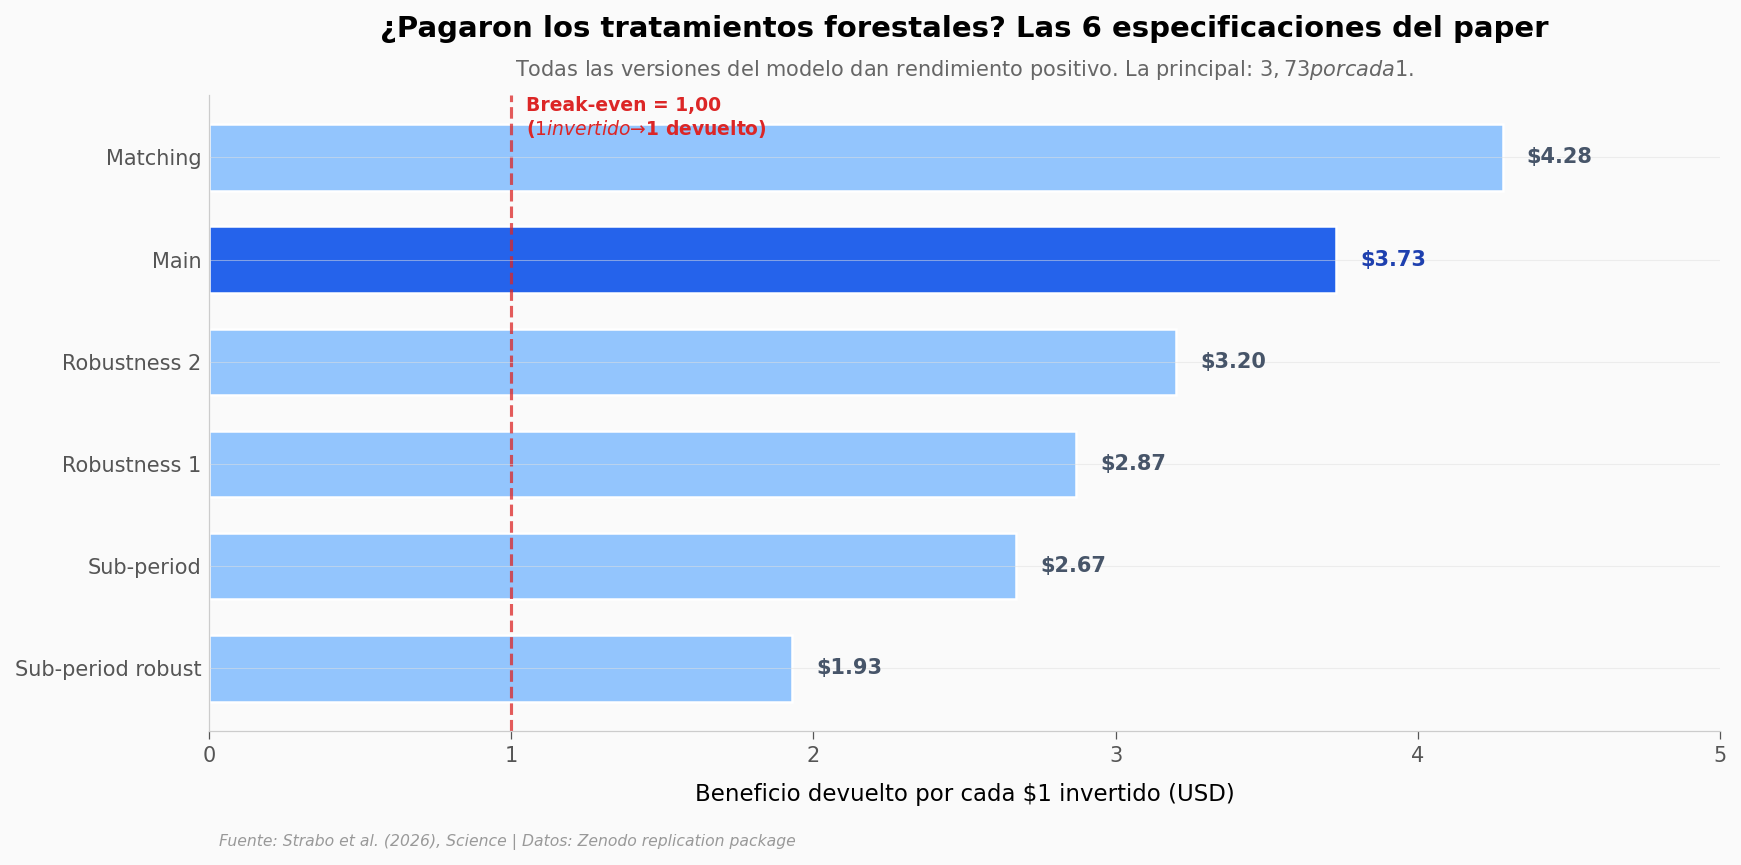

In [2]:
fig, ax = plt.subplots(figsize=(13, 5.5))

# Ordenar por BCR para que sea visualmente legible
bcr_sorted = bcr.sort_values('bcr').reset_index(drop=True)
y_pos = np.arange(len(bcr_sorted))

# Barras horizontales: la principal en azul fuerte, el resto en gris azul
colors = []
for spec in bcr_sorted['specification']:
    if 'Main' in spec:
        colors.append(COLOR_DATOS)
    else:
        colors.append('#93C5FD')  # azul claro

ax.barh(y_pos, bcr_sorted['bcr'], color=colors, edgecolor='white', linewidth=1.2, height=0.65)

# Línea de break-even
ax.axvline(x=BCR_BREAK_EVEN, color=COLOR_ALERTA, linewidth=1.5, linestyle='--', alpha=0.75, zorder=1)
ax.text(BCR_BREAK_EVEN + 0.05, len(bcr_sorted) - 0.4,
        'Break-even = 1,00\n($1 invertido → $1 devuelto)',
        fontsize=9, color=COLOR_ALERTA, fontweight='bold', va='top')

# Valor de cada barra
for i, (val, spec) in enumerate(zip(bcr_sorted['bcr'], bcr_sorted['specification'])):
    ax.text(val + 0.08, i, f'${val:.2f}', fontsize=10, fontweight='bold',
            color='#1E40AF' if 'Main' in spec else '#475569', va='center')

ax.set_yticks(y_pos)
ax.set_yticklabels([s.replace(' (DiD)', '').replace(' (alt)', '') for s in bcr_sorted['specification']],
                    fontsize=10)
ax.set_xlabel('Beneficio devuelto por cada $1 invertido (USD)', fontsize=11)
ax.set_xlim(0, 5)
ax.set_title('¿Pagaron los tratamientos forestales? Las 6 especificaciones del paper',
             fontsize=14, fontweight='bold', pad=28)
ax.text(0.5, 1.03, 'Todas las versiones del modelo dan rendimiento positivo. La principal: $3,73 por cada $1.',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')

fig.text(0.13, -0.03, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/bcr_robustness.png', dpi=200, bbox_inches='tight')
plt.show()

**Lo que llama la atención:** ninguna especificación cae bajo el break-even. La estimación principal (DiD, 700 tratamientos cruzados, ventana 2017-2023) marca **$3,73 por cada $1 invertido**. El resto del rango va de **$1,93 a $4,28** — la peor versión sigue dando rendimiento positivo.

El sub-período más conservador (2017-2020, solo 331 tratamientos) baja a 1,93. Tiene sentido: con menos tratamientos y menos años, el ruido aumenta. La especificación con *matching* sube a 4,28.

Conclusión del paper: bajo todos los escenarios razonables que probaron, los tratamientos forestales pagaron — el beneficio superó el costo. No es un punto-estimado solitario — es un rango consistentemente positivo.

## Dónde se concentró el fuego

Esos 700 tratamientos no estuvieron distribuidos uniformemente. Algunos incendios cruzaron cientos — incluso miles. ¿Cuáles?

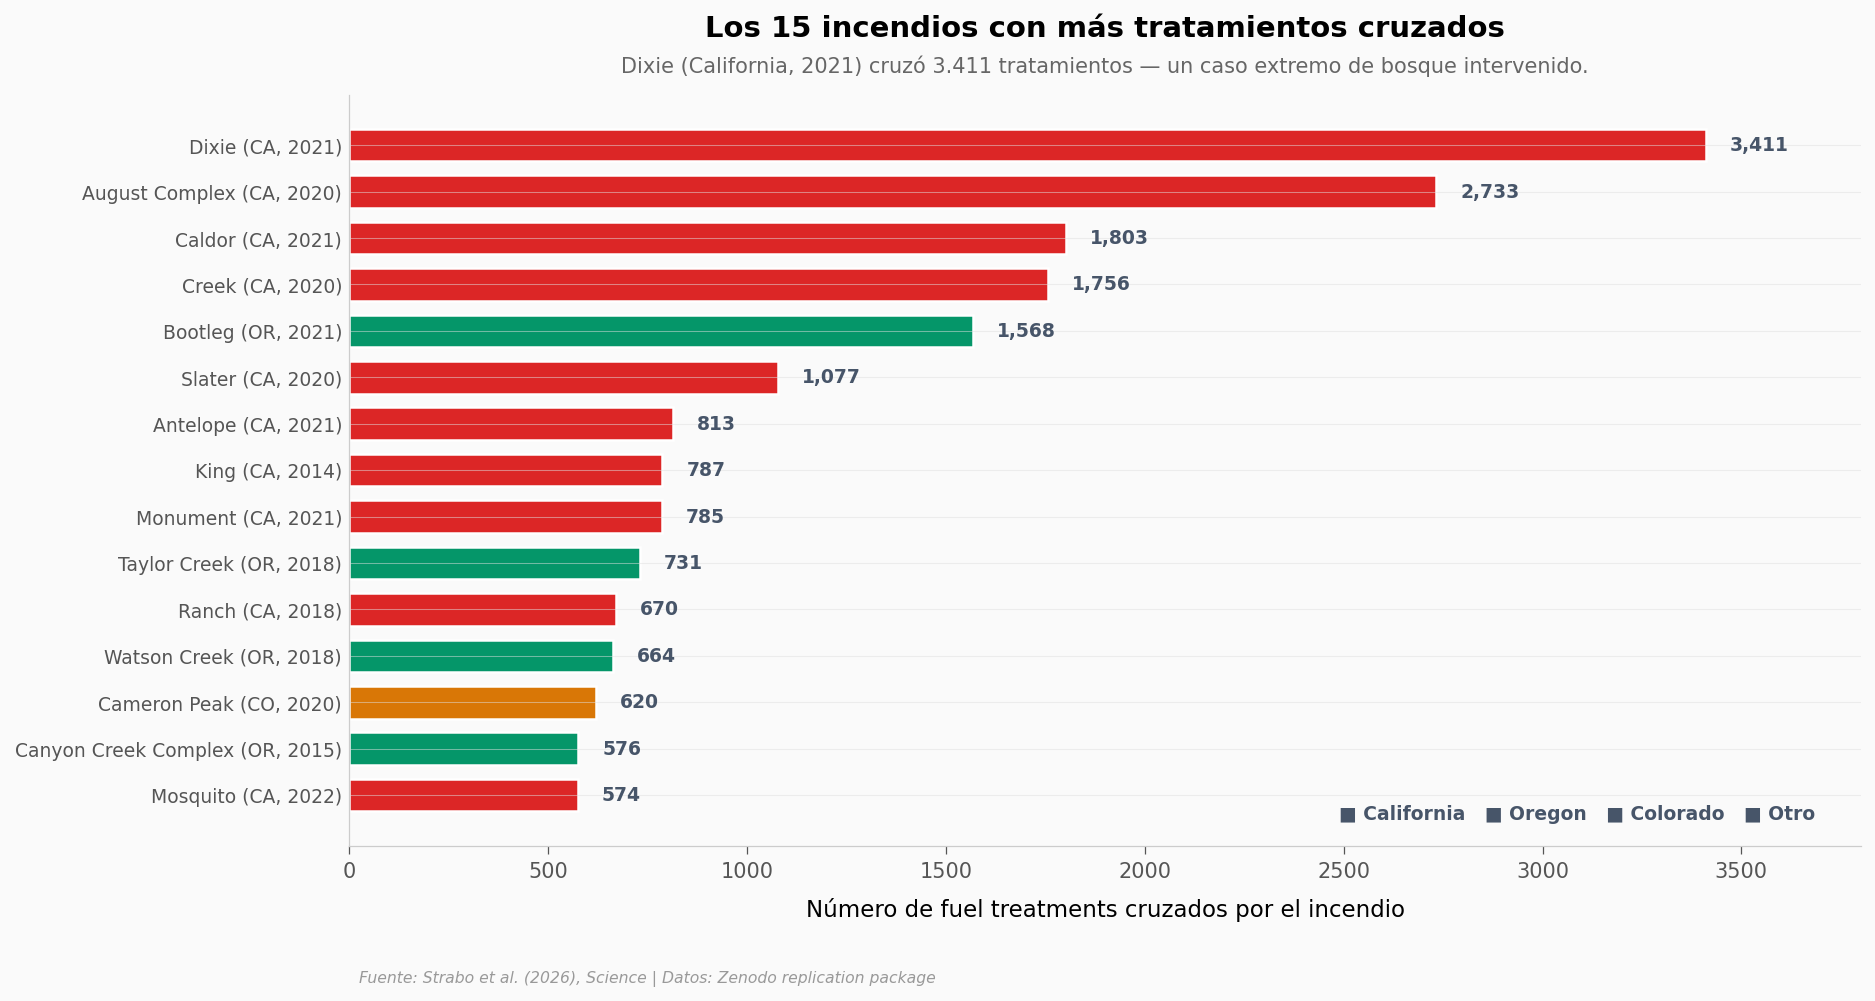

In [3]:
fig, ax = plt.subplots(figsize=(13, 6.5))

# Color por estado
state_palette = {
    'CA': '#DC2626',   # rojo — domina
    'OR': '#059669',   # emerald
    'CO': '#D97706',   # amber
}
top_fires_sorted = top_fires.sort_values('n_treatments').reset_index(drop=True)
bar_colors = [state_palette.get(s, '#7C3AED') for s in top_fires_sorted['state']]

y_pos = np.arange(len(top_fires_sorted))
ax.barh(y_pos, top_fires_sorted['n_treatments'], color=bar_colors,
        edgecolor='white', linewidth=1.2, height=0.7)

# Etiquetas: nombre + estado + año
labels = [f'{r.fire_name.title()} ({r.state}, {r.year})'
          for _, r in top_fires_sorted.iterrows()]
ax.set_yticks(y_pos)
ax.set_yticklabels(labels, fontsize=9)

# Valor de cada barra
for i, val in enumerate(top_fires_sorted['n_treatments']):
    ax.text(val + 60, i, f'{val:,}', fontsize=9, fontweight='bold', color='#475569', va='center')

ax.set_xlabel('Número de fuel treatments cruzados por el incendio', fontsize=11)
ax.set_xlim(0, 3800)
ax.set_title('Los 15 incendios con más tratamientos cruzados',
             fontsize=14, fontweight='bold', pad=28)
ax.text(0.5, 1.03, 'Dixie (California, 2021) cruzó 3.411 tratamientos — un caso extremo de bosque intervenido.',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')

# Leyenda inline de estados (3 más comunes)
ax.text(0.97, 0.03, '■ California   ■ Oregon   ■ Colorado   ■ Otro',
        transform=ax.transAxes, fontsize=9, color='#475569',
        ha='right', va='bottom', fontweight='bold')

fig.text(0.13, -0.03, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/top_fires.png', dpi=200, bbox_inches='tight')
plt.show()

## Lo que el humo deja en el aire — y en los pulmones

Cada incendio aporta dos costos rara vez vistos juntos: las **emisiones de CO₂** (toneladas que vuelven a la atmósfera) y las **partículas PM2.5** (humo respirable que cuesta vidas y dinero en salud). Veamos cómo se distribuyen los 666 incendios con datos de emisiones.

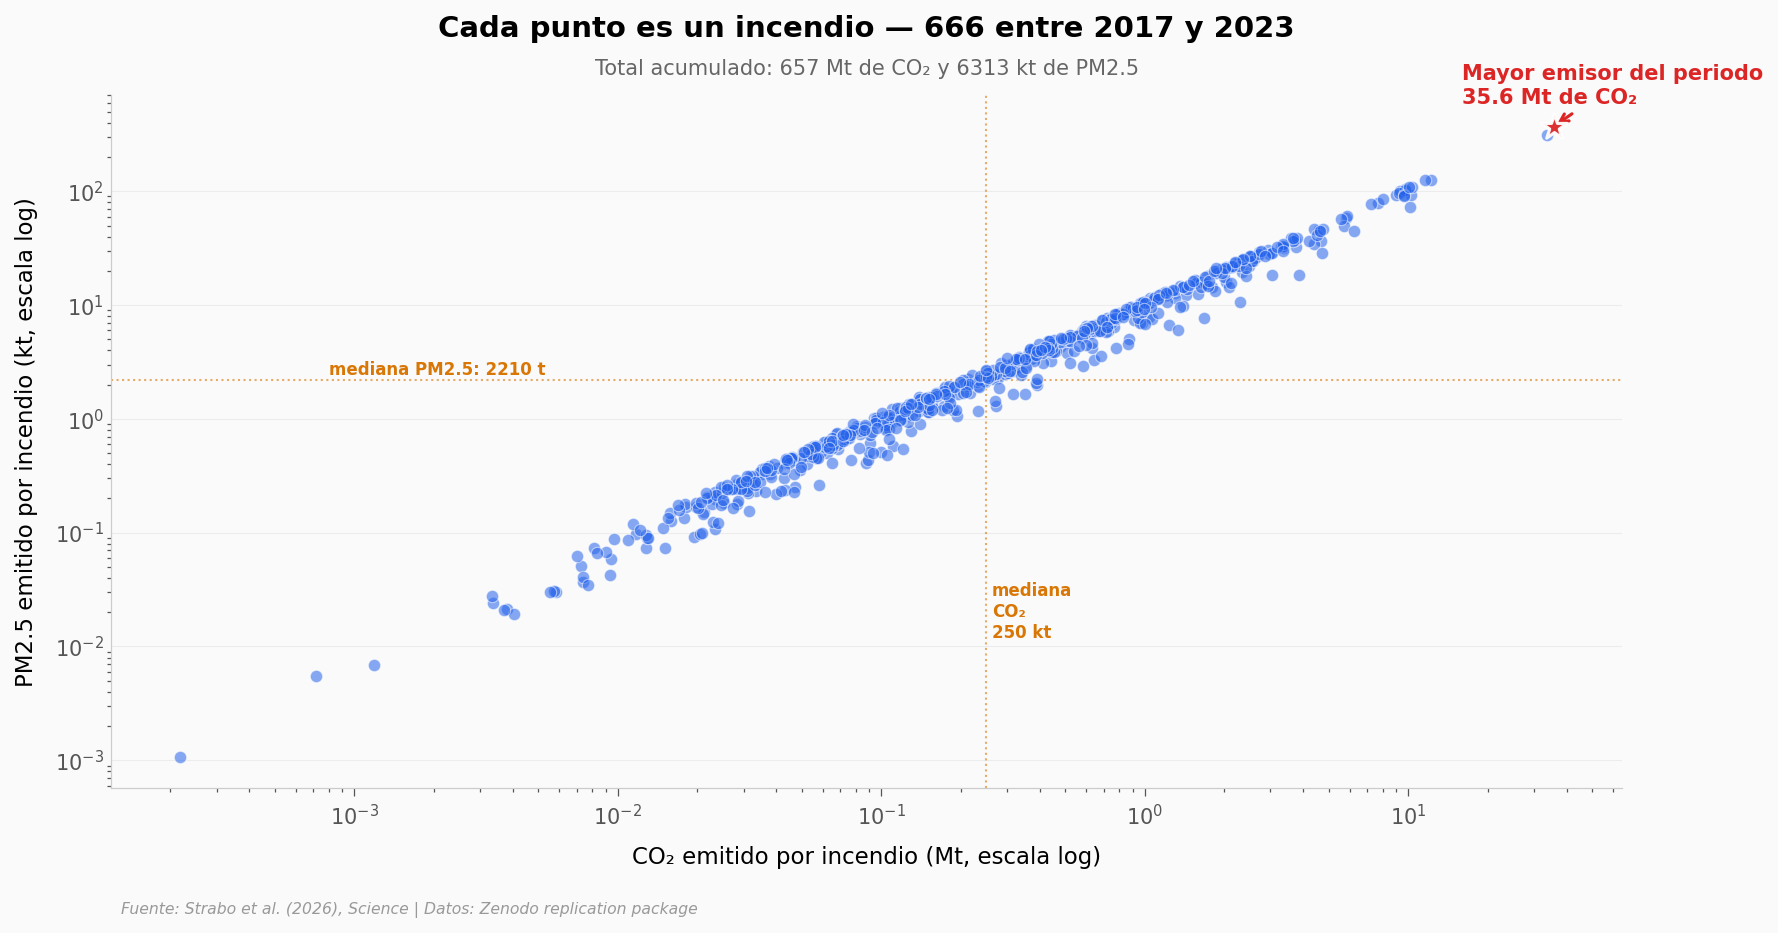

In [4]:
fig, ax = plt.subplots(figsize=(13, 6))

# Convertir a unidades cómodas (Mt y kt)
co2_mt = emissions['co2_tonnes'] / 1e6
pm25_kt = emissions['pm25_tonnes'] / 1e3

# Identificar Dixie como el extremo (mayor CO₂)
top_idx = emissions['co2_tonnes'].idxmax()
top_co2 = co2_mt[top_idx]
top_pm25 = pm25_kt[top_idx]

# Scatter principal — el rest
mask_other = emissions.index != top_idx
ax.scatter(co2_mt[mask_other], pm25_kt[mask_other],
           color=COLOR_DATOS, s=35, alpha=0.55,
           edgecolors='white', linewidths=0.5, zorder=4)

# Punto extremo — Dixie / fire_id de mayor CO2
ax.scatter([top_co2], [top_pm25], color=COLOR_ALERTA, s=160, alpha=0.95,
           edgecolors='white', linewidths=1.5, zorder=6,
           marker='*')
ax.annotate(f'Mayor emisor del periodo\n{top_co2:.1f} Mt de CO\u2082',
            xy=(top_co2, top_pm25), xytext=(top_co2 * 0.45, top_pm25 * 1.6),
            fontsize=10, fontweight='bold', color=COLOR_ALERTA,
            arrowprops=dict(arrowstyle='->', color=COLOR_ALERTA, lw=1.5))

# Medianas como referencia
co2_med = co2_mt.median()
pm25_med = pm25_kt.median()
ax.axvline(x=co2_med, color=COLOR_REFERENCIA, linewidth=1, linestyle=':', alpha=0.6, zorder=2)
ax.axhline(y=pm25_med, color=COLOR_REFERENCIA, linewidth=1, linestyle=':', alpha=0.6, zorder=2)
ax.text(co2_med * 1.05, 0.012, f'mediana\nCO\u2082\n{co2_med*1000:.0f} kt',
        fontsize=8, color=COLOR_REFERENCIA, fontweight='bold')
ax.text(0.0008, pm25_med * 1.1, f'mediana PM2.5: {pm25_med*1000:.0f} t',
        fontsize=8, color=COLOR_REFERENCIA, fontweight='bold')

ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel('CO\u2082 emitido por incendio (Mt, escala log)', fontsize=11)
ax.set_ylabel('PM2.5 emitido por incendio (kt, escala log)', fontsize=11)
ax.set_title(f'Cada punto es un incendio — {len(emissions)} entre 2017 y 2023',
             fontsize=14, fontweight='bold', pad=28)
ax.text(0.5, 1.03, f'Total acumulado: {co2_mt.sum():.0f} Mt de CO\u2082 y {pm25_kt.sum():.0f} kt de PM2.5',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')

fig.text(0.13, -0.03, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/co2_pm25.png', dpi=200, bbox_inches='tight')
plt.show()

## ¿Qué tan asimétrico es el daño?

La mediana del periodo emite ~250.000 toneladas de CO₂. Pero un solo incendio puede emitir más de 35 millones. ¿Qué forma tiene esa distribución?

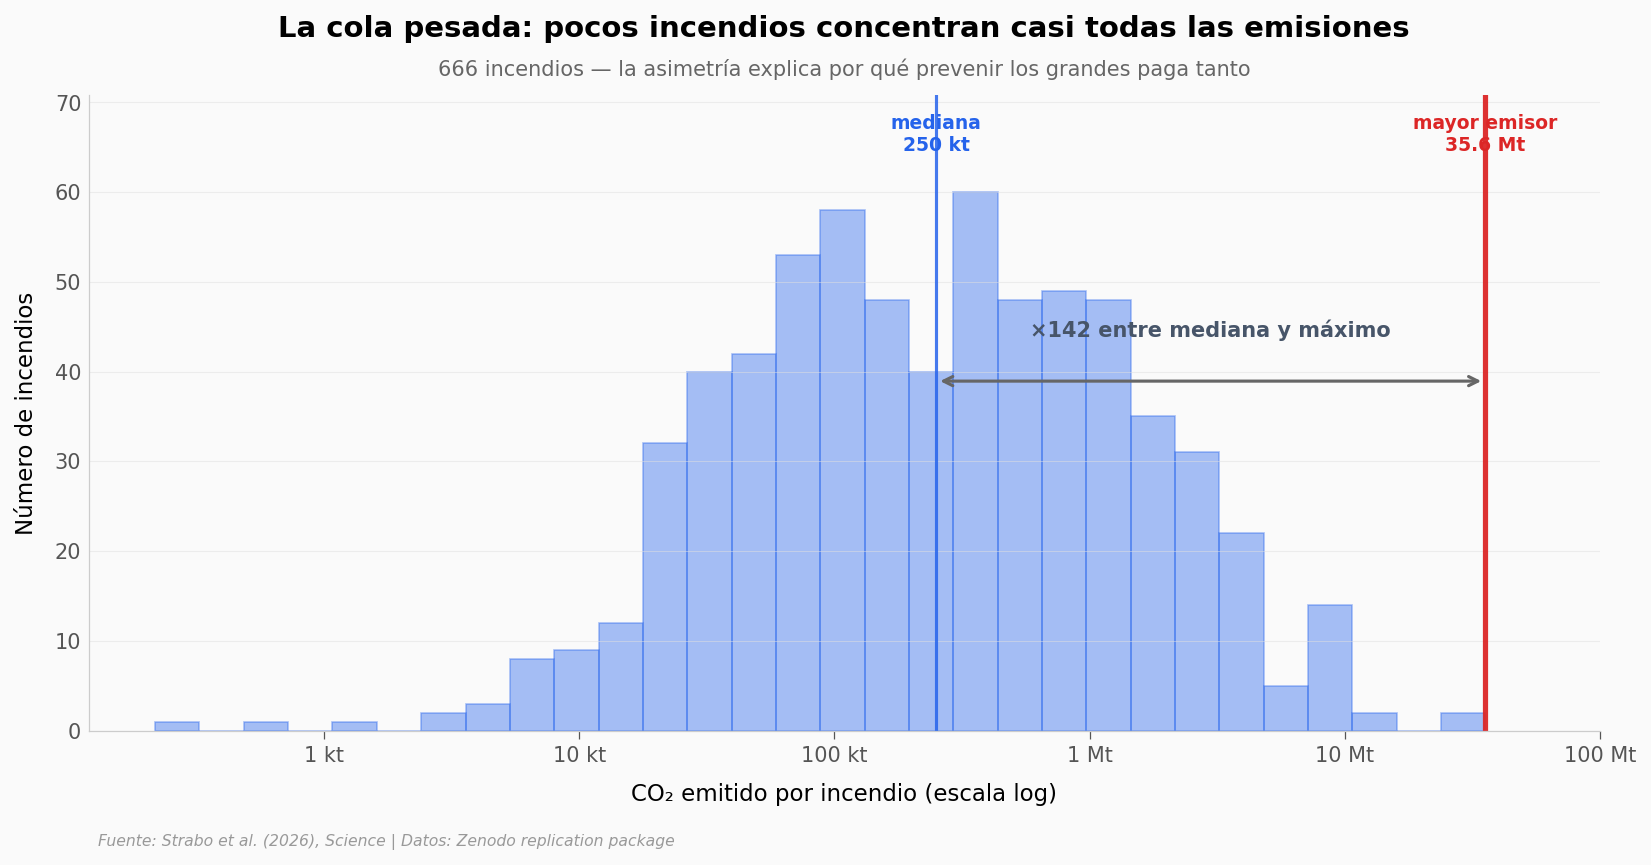

In [5]:
fig, ax = plt.subplots(figsize=(13, 5.5))

# CO₂ en Mt, escala log para visualizar la cola larga
co2_mt = emissions['co2_tonnes'] / 1e6
log_co2 = np.log10(emissions['co2_tonnes'].clip(lower=1))

n, bins, patches = ax.hist(log_co2, bins=30, color=COLOR_DATOS, alpha=0.4,
                           edgecolor=COLOR_DATOS, linewidth=0.8)
y_max = n.max() * 1.18
ax.set_ylim(0, y_max)

# Línea: mediana
log_med = np.log10(emissions['co2_tonnes'].median())
ax.axvline(x=log_med, color=COLOR_DATOS, linewidth=1.5, alpha=0.85)
ax.text(log_med, y_max * 0.97, f'mediana\n{emissions.co2_tonnes.median()/1e3:.0f} kt',
        fontsize=9, color=COLOR_DATOS, fontweight='bold', ha='center', va='top')

# Línea: incendio extremo
log_max = np.log10(emissions['co2_tonnes'].max())
ax.axvline(x=log_max, color=COLOR_ALERTA, linewidth=2.5, alpha=0.95)
ax.text(log_max, y_max * 0.97, f'mayor emisor\n{emissions.co2_tonnes.max()/1e6:.1f} Mt',
        fontsize=9, color=COLOR_ALERTA, fontweight='bold', ha='center', va='top')

# Flecha bidireccional entre los dos
ax.annotate('', xy=(log_max, y_max * 0.55), xytext=(log_med, y_max * 0.55),
            arrowprops=dict(arrowstyle='<->', color='#666666', lw=1.5))
factor = emissions.co2_tonnes.max() / emissions.co2_tonnes.median()
ax.text((log_med + log_max) / 2, y_max * 0.62,
        f'×{factor:,.0f} entre mediana y máximo',
        fontsize=10, color='#475569', fontweight='bold', ha='center')

# Eje X: convertir log10 → tonnes legible
ticks_log = [3, 4, 5, 6, 7, 8]
tick_labels = ['1 kt', '10 kt', '100 kt', '1 Mt', '10 Mt', '100 Mt']
ax.set_xticks(ticks_log)
ax.set_xticklabels(tick_labels, fontsize=10)
ax.set_xlabel('CO\u2082 emitido por incendio (escala log)', fontsize=11)
ax.set_ylabel('Número de incendios', fontsize=11)
ax.set_title('La cola pesada: pocos incendios concentran casi todas las emisiones',
             fontsize=14, fontweight='bold', pad=28)
ax.text(0.5, 1.03,
        f'{len(emissions)} incendios — la asimetría explica por qué prevenir los grandes paga tanto',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')

fig.text(0.13, -0.03, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/co2_distribution.png', dpi=200, bbox_inches='tight')
plt.show()

## Lo que los datos soportan

| Afirmación | ¿Soportada? | Detalle |
|---|---|---|
| BCR principal = $3,73 por cada $1 invertido | ✅ | Verificado en `bcr_robustness.csv` fila 1 (Main DiD, 700 tratamientos, 2017-2023) |
| Rango de robustez 1,93 – 4,28 | ✅ | Las 6 especificaciones del CSV están todas por encima del break-even |
| $2.800 millones en daños evitados (total agregado) | ⚠️ | Reportado en el abstract de *Science*. No tenemos el desglose completo en los CSVs procesados — el paper integra estructuras + emisiones + salud y reporta el agregado |
| 9.863 incendios MTBS en el universo (2006-2023) | ✅ | Suma directa de `mtbs_annual_fires.csv` |
| Dixie (CA, 2021) cruzó 3.411 tratamientos | ✅ | Top fila de `top_treated_fires.csv` |
| 10.321 muertes atribuidas a humo PM2.5 | ✅ | Suma de `fire_smoke_health.csv` (atribución metodológica de Wen et al. 2023, no propia del paper) |
| 657 Mt de CO₂ totales y 6.313 kt de PM2.5 (2017-2023) | ✅ | Sumas de `fire_emissions.csv` |

> **Limitaciones que el lector debe conocer:**
> - **Diseño cuasi-experimental, no RCT.** La identificación causal viene de la exogenidad espacial — la dirección y distancia con que el fuego encuentra los tratamientos previos. Permite afirmar *"los tratamientos redujeron daños"*, pero no *"siempre apagan fuegos"*.
> - **Geografía concentrada.** California aporta 202 de los 666 incendios con datos de emisiones (30%). El resultado refleja sobre todo el oeste norteamericano — extrapolar al Mediterráneo, Australia o Chile requiere más trabajo.
> - **Daños en salud son atribuciones modeladas.** Las muertes vienen de un modelo epidemiológico (Wen 2023), no de certificados de defunción. Es la mejor estimación disponible, no una cuenta exacta.
> - **Datasets crudos del paper son enormes** (6,5 GB con 1.130 archivos). Acá usamos los 5 CSVs procesados que contienen los outputs analíticos finales — no es muestreo, son los resultados completos publicados.

## Ahora tú

1. **¿Cómo cambia el BCR si miras solo California?** Los CSVs no traen el BCR desagregado por estado, pero sí los conteos. ¿Qué porcentaje de los tratamientos cruzados está en CA? *(Pista: combina `top_treated_fires.csv` con `fire_emissions.state.value_counts()`.)*
2. **¿Qué fracción de las emisiones totales aporta el top-5 de incendios?** *(Pista: ordena `emissions['co2_tonnes']` descendente, suma los primeros 5, divide entre el total.)*
3. **¿Hay relación entre `n_treatments` y daño evitado?** *(Pista: el CSV `top_treated_fires.csv` no incluye daño — pero puedes contrastar Dixie 2021 con incendios sin tratamientos del mismo año en `mtbs_annual_fires.csv`.)*

In [6]:
# --- EXPERIMENTA AQUÍ ---
# Prueba: ¿qué fracción del CO₂ total aporta el top-5 de incendios?

top5 = emissions.nlargest(5, 'co2_tonnes')
fraccion = top5['co2_tonnes'].sum() / emissions['co2_tonnes'].sum()

print(f'Top 5 incendios:')
for _, r in top5.iterrows():
    print(f"  {r.fire_id}  ({r.year})  →  {r.co2_tonnes/1e6:6.2f} Mt")
print(f'\nSuma top 5:  {top5.co2_tonnes.sum()/1e6:.1f} Mt de CO\u2082')
print(f'Total 666 incendios: {emissions.co2_tonnes.sum()/1e6:.1f} Mt')
print(f'Fracción concentrada en top 5: {fraccion*100:.1f}%')

Top 5 incendios:
  CA3987612137920210714  (2021)  →   35.61 Mt
  CA3966012280920200817  (2020)  →   33.73 Mt
  CA3720111927220200905  (2020)  →   12.15 Mt
  CA4009112093120200817  (2020)  →   11.59 Mt
  OR4482112218820200816  (2020)  →   10.34 Mt

Suma top 5:  103.4 Mt de CO₂
Total 666 incendios: 657.3 Mt
Fracción concentrada en top 5: 15.7%


## Fuentes

**Paper**: [Wildfire damages and the cost-effective role of forest fuel treatments](https://doi.org/10.1126/science.aea6463)  
*Science, 2026-05-07* · paywall

**Datos**: [Replication package for "Wildfire damages and the cost-effective role of forest fuel treatments" — Strabo, Bryan, Reimer (2026)](https://doi.org/10.5281/zenodo.18882334)  
*Replication package — 6,5 GB, usamos 5 CSVs procesados con outputs analíticos finales*

*15 afirmaciones del notebook verificadas contra estas fuentes*

---

**Reproducibilidad**: este notebook se ejecuta entero con `pip install pandas matplotlib numpy` y los 5 CSVs en `datos/`. Los datos crudos completos están en el [replication package de Zenodo](https://doi.org/10.1126/science.aea6463).

**Repo**: [github.com/Ciencia-a-Mordiscos/lab](https://github.com/Ciencia-a-Mordiscos/lab) · **Licencia**: CC-BY 4.0 · **Canal**: [@cienciaamordiscos](https://www.youtube.com/@cienciaamordiscos)